In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Несмещённые оценки

Оценка $\hat{\theta}_n$ **несмещённая**, если $ \mathbb{E}(\hat{\theta}_n) = \theta$.

Будем генерировать выборки размером 10 из стандартного нормального распределения.</br>
Построим оценки распределений и вычислим среднее для следующих статистик:
- среднее;
- минимум;
- первый элемент выборки.

mean(mean) = 0.001094
mean(min) = -1.532284
mean(first) = -0.000283


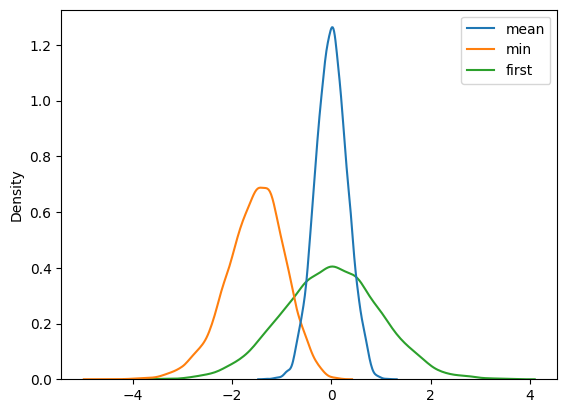

In [3]:
n = 10
n_iter = 10000

data = np.random.normal(size=(n_iter, n))
dict_stats = {
    'mean': data.mean(axis=1),
    'min': data.min(axis=1),
    'first': data[:, 0]
}

for stat_name, stat_values in dict_stats.items():
    print(f'mean({stat_name}) = {stat_values.mean():0.6f}')
sns.kdeplot(data=dict_stats, common_norm=False);

## 2. Состоятельные оценки

Оценка $\hat{\theta}_n$ **состоятельная**, если $\hat{\theta}_n \xrightarrow{\mathbb{P}} \theta$.

Для разных размеров выборки будем генерировать данные по 30 раз и оценивать разброс статистики.

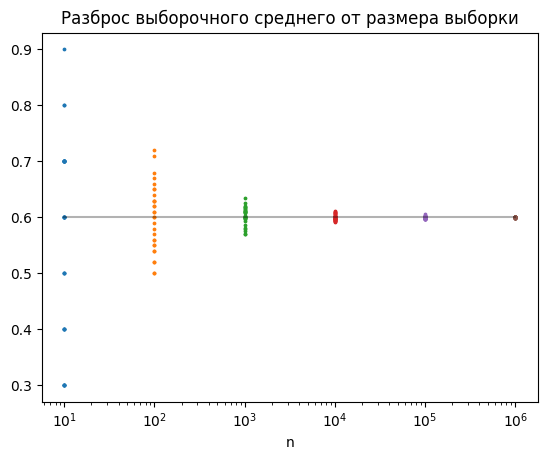

In [4]:
n_iter = 30
p = 0.6

plt.plot([10, 1e6], [p, p], 'k', alpha=0.3)
for n in np.logspace(1, 6, 6).astype(int):
    data = np.random.binomial(n=1, p=p, size=(n_iter, n))
    means = data.mean(axis=1)
    plt.scatter(np.full(n_iter, fill_value=n), means, s=3)
plt.xscale('log')
plt.title('Разброс выборочного среднего от размера выборки')
plt.xlabel('n');

## 3. Оценка дисперсии

Смещённая оценка дисперсии:
$$
\hat{\sigma}^2_n = \dfrac{1}{n} \sum_{i=1}^n (X_i - \hat{m})^2\ \ \ \ \text{ , где } \hat{m}=\dfrac{\sum_{i=1}^n X_i}{n}
$$

Несмещённая оценка дисперсии:
$$
\hat{\sigma}^2_n = \dfrac{1}{n-1} \sum_{i=1}^n (X_i - \hat{m})^2
$$

Построим оценки распределений для смещённой и несмещённой оценок дисперсии по выборкам размера 10.

mean(var ddof=0) = 0.900108
mean(var ddof=1) = 1.000121


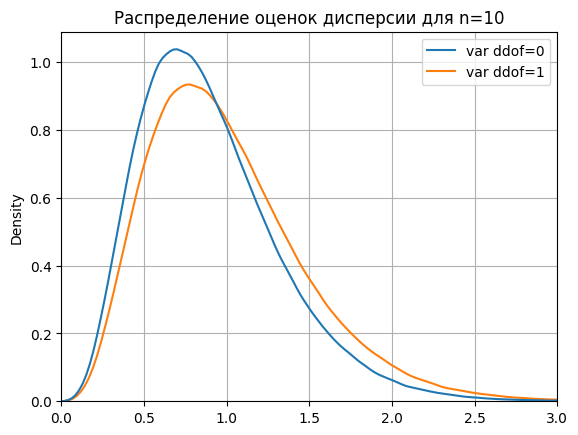

In [ ]:
n = 10
n_iter = 1000000

data = np.random.normal(size=(n_iter, n))
dict_stats = {
    'var ddof=0': data.var(axis=1, ddof=0),
    'var ddof=1': data.var(axis=1, ddof=1),
}

for stat_name, stat_values in dict_stats.items():
    print(f'mean({stat_name}) = {stat_values.mean():0.6f}')
sns.kdeplot(data=dict_stats, common_norm=False)
plt.xlim([0, 3])
plt.title('Распределение оценок дисперсии для n=10')
plt.grid();

## 4. Эмпирическая функция распределения

Эмпирическая функция распределения:
$$
\hat{F}_n(x) = \frac{\sum_{i=1}^n I(X_i < x)}{n}\quad ,\text{где}\
I(X_i < x)=
\left\{
\begin{aligned}
1, X_i < x \\
0, X_i \ge x
\end{aligned}
\right.
$$

Проиллюстрируем построение ЭФР по 10 точкам.

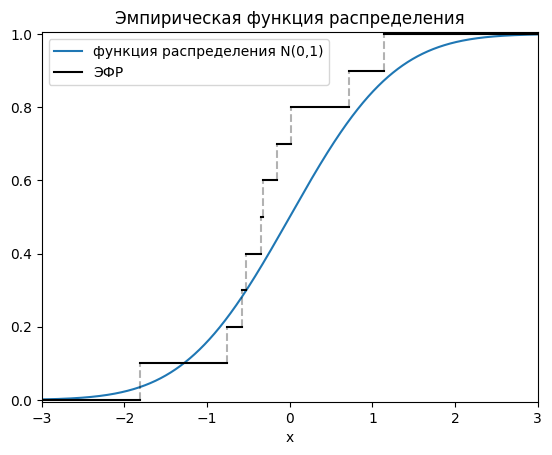

In [ ]:
n = 10
data = np.random.normal(size=n)

xlim = [-3, 3]
X = np.linspace(xlim[0], xlim[1], 10000)
Y = stats.norm.cdf(X)
plt.plot(X, Y, label='функция распределения N(0,1)')

data.sort()
plt.plot([data[0]-10, data[0]], [0, 0], '-k', label='ЭФР')
plt.plot([data[-1], data[-1]+10], [1, 1], '-k')


prev_h = 0
for a, b in zip(data[:-1], data[1:]):
    h = (data < b).mean()
    plt.plot([a, b], [h, h], '-k')
    plt.vlines(a, prev_h, h, linestyles='--', colors='k', alpha=0.3)
    prev_h = h
plt.vlines(b, h, 1, linestyles='--', colors='k', alpha=0.3)

plt.xlim(xlim)
plt.ylim([-0.005, 1.005])
plt.xlabel('x')
plt.title('Эмпирическая функция распределения')
plt.legend();

Убедимся, что с ростом количества наблюдений ЭФР сходится к ФР.

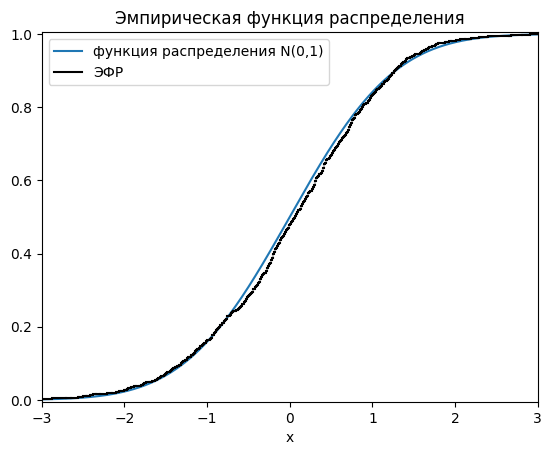

In [ ]:
n = 1000
data = np.random.normal(size=n)

xlim = [-3, 3]
X = np.linspace(xlim[0], xlim[1], 10000)
Y = stats.norm.cdf(X)
plt.plot(X, Y, label='функция распределения N(0,1)')

data.sort()
plt.plot([data[0]-10, data[0]], [0, 0], '-k', label='ЭФР')
plt.plot([data[-1], data[-1]+10], [1, 1], '-k')

prev_h = 0
for a, b in zip(data[:-1], data[1:]):
    h = (data < b).mean()
    plt.plot([a, b], [h, h], '-k')
    plt.vlines(a, prev_h, h, linestyles='--', colors='k', alpha=0.3)
    prev_h = h
plt.vlines(b, h, 1, linestyles='--', colors='k', alpha=0.3)

plt.xlim(xlim)
plt.ylim([-0.005, 1.005])
plt.xlabel('x')
plt.title('Эмпирическая функция распределения')
plt.legend();

## 5. Центральная предельная теорема

**Центральная предельная теорема**</br>
Пусть $X_1, \ldots, X_n$ независимые одинаково распределённые случайные величины, имеющие конечные среднее $m$ и диспресию $𝜎^2$. Тогда

$$
\dfrac{\overline{X}_n - m }{\sigma / \sqrt{n}} \to N(0, 1) \quad \text{, где}\ \overline{X}_n=\dfrac{\sum_{i=1}^n X_i}{n}
$$

Посмотрим как меняется распределение среднего для выборки из равномерного распределения $U(0, 1)$ с увеличением размера выборки.

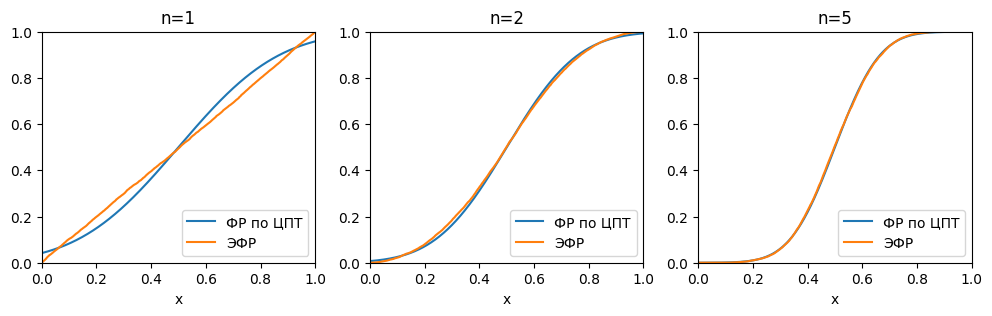

In [ ]:
n_iter = 10000
X = np.linspace(0, 1, 1000)
std = (1/12) ** 0.5

fig, axes = plt.subplots(1, 3, figsize=[12,3])
for n, ax in zip([1, 2, 5], axes):
    Y_norm = stats.norm.cdf(X, loc=0.5, scale=std/n**0.5)
    ax.plot(X, Y_norm, label='ФР по ЦПТ')
    data = np.random.uniform(size=(n_iter, n))
    means = data.mean(axis=1)
    Y_ecdf = [np.mean(means <= x) for x in X]
    ax.plot(X, Y_ecdf, label=f'ЭФР')
    ax.legend(loc=4)
    ax.set_title(f'n={n}')
    ax.set_xlabel('x')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
plt.show()